<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 50%, #0a0a1a 100%); padding: 40px 32px 32px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-bottom: 8px;">

<div style="display: flex; align-items: flex-start; gap: 24px;">
<div style="flex: 1;">

<p style="color: #7eb8e0; font-family: 'Courier New', monospace; font-size: 20px; letter-spacing: 3px; margin: 0 0 10px 0; text-transform: uppercase;">Cosmic Explosion Exploration - LIGO Gravitational Wave Analysis Pipeline</p>

<h1 style="color: #e8f4fd; font-size: 2.2em; margin: 0 0 6px 0; font-weight: 300; letter-spacing: 1px;">Notebook 03 — Visualisation</h1>

<p style="color: #a0c4de; font-size: 1.05em; margin: 0 0 20px 0; font-style: italic;">Time-series, spectrograms, Q-transforms, and detector correlation</p>

<div style="display: flex; gap: 24px; flex-wrap: wrap;">
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Inputs</p>
    <p style="color: #e8f4fd; font-size: 0.95em; font-weight: 600; margin: 0; font-family: 'Courier New', monospace;">*_raw.hdf5 · *_processed.hdf5</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">from notebooks 01 &amp; 02</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Outputs</p>
    <p style="color: #e8f4fd; font-size: 0.95em; font-weight: 600; margin: 0; font-family: 'Courier New', monospace;">9 × PNG figures</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">saved to data/visualisations/</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Pipeline stage</p>
    <p style="color: #e8f4fd; font-size: 1.2em; font-weight: 600; margin: 0;">03 of 06</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">time-series · spectrogram · Q-transform</p>
  </div>
</div>

</div>
</div>

<hr style="border: none; border-top: 1px solid rgba(126,184,224,0.2); margin: 24px 0 16px 0;">

<p style="color: #7eb8e0; font-size: 12px; font-family: 'Courier New', monospace; margin: 0;">
  <span style="opacity:0.6;">Pipeline:</span> &nbsp;
</p>

</div>

In [1]:
from pipeline_banner import pipeline_banner
pipeline_banner(3)   # ← change the number per notebook

## How Do We Actually *See* a Gravitational Wave?

Raw strain data is overwhelmingly noise. After applying some preprocessing techniques, this data - the chirp signal starts to become visible — but no single representation tells the whole story. This notebook works through a progression of visualisation techniques, each revealing a different aspect of the signal:

| Section | Technique | What it reveals |
|---------|-----------|----------------|
| 3 | Time-series overview | Raw noise vs processed signal across the full 32 s segment |
| 4 | Zoomed chirp window | Inspiral, merger, and ringdown phases in ±0.5 s |
| 5 | ASD comparison | Noise floor before and after conditioning |
| 6 | STFT Spectrogram | Frequency content over time — and its limitations |
| 7–8 | Q-transform | The chirp arc — the gold standard for Gravitational Wave visualisation |
| 9–10 | SNR windows | Quantitative signal-to-noise comparison |
| 11 | Detector correlation | H1/L1 waveform alignment as a reality check |

We only touch on some of the techniques used by LIGO scientists in this project but it gives an appreciation of the complexity of the measured signals and sensitivity to external factors.

All parameters — zoom windows, phase marker times, detector offsets — are sourced from `config.py`. 
To adapt this notebook to a different event, update `EVENT.NAME` in `config.py` and re-run.

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 0 — Environment Setup</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Imports, pipeline wiring, and matplotlib theme. All parameters come from <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">config.py</code> — including phase markers, detector offsets, and zoom windows.</p>
</div>

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import sys

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.signal import spectrogram as scipy_spectrogram

# ── LIGO-specific ─────────────────────────────────────────────────────────────
from gwpy.timeseries import TimeSeries

# ── Pipeline modules ──────────────────────────────────────────────────────────
sys.path.insert(0, ".")
from config import PATHS, EVENT, SIGNAL, VIZ, PHASE_MARKERS, DETECTOR_CORRELATION
from utils import (
    load_raw_hdf5,
    load_processed_hdf5,
    time_relative_to_merger,
    crop_to_window,
    estimate_snr,
    plot_qtransform,
    check_pipeline_files,
)

%matplotlib inline
PATHS.make_dirs()
print("✓ Imports complete.")

✓ Imports complete.


In [2]:
# ── Deep-space matplotlib theme (mirrors notebooks 01 & 02) ───────────────────
SPACE_BG     = "#0d1117"
SPACE_AXES   = "#131c27"
SPACE_GRID   = "#1e2d3e"
SPACE_TEXT   = "#c9d9e8"
SPACE_BORDER = "#2a4a6e"

# Wes Anderson detector palette — warm coral (H1), dusty teal (L1), golden (V1)
WA_COLOURS = {
    "H1":        "#E07B54",   # Warm coral-orange
    "L1":        "#5AAFA0",   # Dusty teal-green
    "V1":        "#D4A84B",   # Warm golden sand
    "merger":    "#F2C46D",   # Butter-yellow
    "inspiral":  "#A8C5DA",   # Pale blue
    "ringdown":  "#C4A8DA",   # Soft lilac
    "noise_win": "#4a7abf",   # Muted blue for noise window shading
    "sig_win":   "#C4704A",   # Warm coral for signal window shading
    "bandpass":  "#8BBF9F",   # Sage for bandpass shading
}

plt.rcParams.update({
    "figure.facecolor":  SPACE_BG,
    "axes.facecolor":    SPACE_AXES,
    "savefig.facecolor": SPACE_BG,
    "text.color":        SPACE_TEXT,
    "axes.labelcolor":   SPACE_TEXT,
    "xtick.color":       SPACE_TEXT,
    "ytick.color":       SPACE_TEXT,
    "axes.edgecolor":    SPACE_BORDER,
    "grid.color":        SPACE_GRID,
    "grid.linewidth":    0.6,
    "axes.grid":         True,
    "axes.grid.which":   "both",
    "axes.titlesize":    12,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "lines.linewidth":   0.9,
    "axes.linewidth":    0.8,
    "figure.constrained_layout.use": True,
})

print("✓ Deep-space theme applied.")

✓ Deep-space theme applied.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 1 — Pipeline Pre-checks &amp; Data Load</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Verify upstream notebooks have run, then load both raw and processed strain. Raw data shows the noise baseline; processed data reveals the conditioned signal.</p>
</div>

In [3]:
# Confirm notebooks 01 and 02 have been run
check_pipeline_files(EVENT.NAME)

# Load raw strain (notebook 01 output)
raw = load_raw_hdf5(EVENT.NAME)

# Load processed strain and the conditioning parameters applied in notebook 02
processed, prep_params = load_processed_hdf5(EVENT.NAME)

print()
print("Preprocessing parameters applied in notebook 02:")
for k, v in prep_params.items():
    print(f"  {k}: {v}")

# Resolve event-specific config entries
phases = PHASE_MARKERS.get(EVENT.NAME, {})
corr   = DETECTOR_CORRELATION.get(EVENT.NAME, {})

print()
print(f"Phase markers for {EVENT.NAME}: {phases}")
print(f"Detector correlation config  : {corr}")

Pipeline file check — GW150914:
  [✓] Raw HDF5 (notebook 01): data\raw\GW150914_raw.hdf5
  [✓] Processed HDF5 (notebook 02): data\processed\GW150914_processed.hdf5

All upstream files present. Ready to proceed.
Loaded raw data (GW150914): H1 [131072 samples], L1 [131072 samples]
Loaded processed data (GW150914): H1 [131072 samples], L1 [131072 samples]
Preprocessing applied: ['whiten' 'bandpass' 'notch']

Preprocessing parameters applied in notebook 02:
  bandpass_high_hz: 350.0
  bandpass_low_hz: 35.0
  bandpass_order: 4
  notch_freqs_hz: [ 60. 120. 180.]
  notch_q: 30.0
  steps_applied: ['whiten' 'bandpass' 'notch']
  whiten_fftlength: 4

Phase markers for GW150914: {'inspiral_end': -0.1, 'merger': 0.0, 'ringdown_start': 0.05}
Detector correlation config  : {'time_shift_s': 0.007, 'sign_flip': -1, 'crop_window': (-0.45, 0.1)}


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 2 — Time-Series Overview: Full Segment</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">The x-axis is GPS time relative to the merger (t = 0). Raw strain (left) is dominated by broadband noise. Processed strain (right) reveals the signal after whitening, bandpass, and notch filtering. Each panel includes an inset zoom centred on the merger.</p>
</div>

### Reading this plot

The x-axis shows **time in seconds relative to the merger** — the moment the two black holes collided, at GPS 1126259462. Negative values are before the merger; positive are after.

The y-axis is **strain** — the fractional change in the interferometer arm length caused by the passing wave. GW150914 changed LIGO's 4 km arms by roughly 4 × 10⁻¹⁸ m — about one-thousandth the diameter of a proton.

The raw data (left) looks like random noise because it *is* dominated by noise. The processed data (right) has been whitened, bandpassed, and notch-filtered. The brief oscillation around t = 0 — invisible in the raw data — is the gravitational wave chirp. The inset zoom on each panel magnifies the ±0.2 s window around the merger.

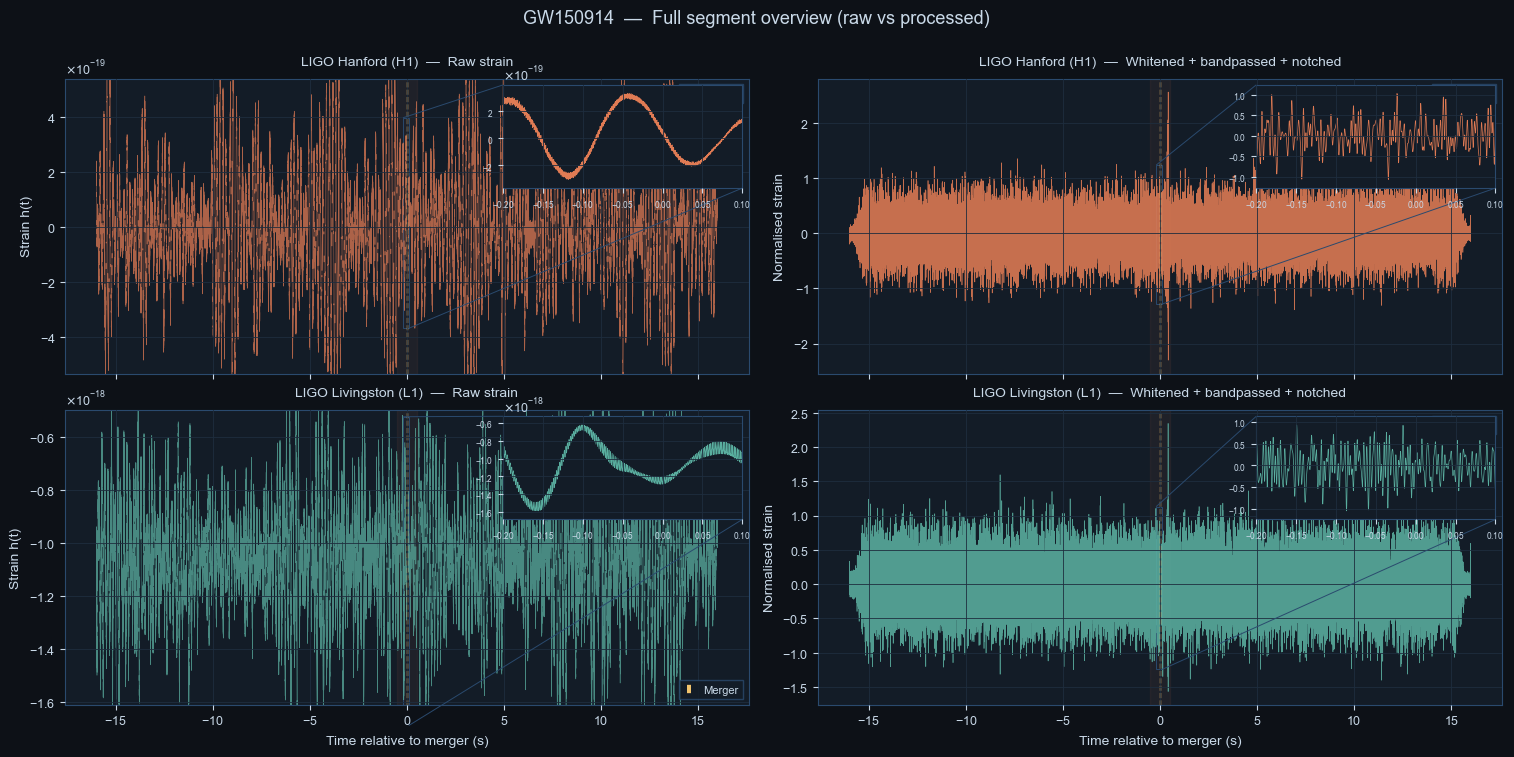

Figure saved → data\visualisations\GW150914_overview_raw_vs_processed.png


In [16]:
def _add_zoom_inset(ax, t, y, xlim=VIZ.ZOOM_INSET_WINDOW):
    """
    Add a zoomed inset panel to an existing axes.
    xlim is sourced from VIZ.ZOOM_INSET_WINDOW in config.py.
    """
    axins = inset_axes(ax, width="35%", height="35%", loc="upper right")
    axins.set_facecolor(SPACE_AXES)
    axins.plot(t, y, lw=0.5, color=ax.lines[0].get_color())
    axins.set_xlim(*xlim)
    mask = (t >= xlim[0]) & (t <= xlim[1])
    if mask.any():
        y_z = y[mask]
        pad = (y_z.max() - y_z.min()) * 0.1 or 1e-21
        axins.set_ylim(y_z.min() - pad, y_z.max() + pad)
    axins.tick_params(labelsize=6, colors=SPACE_TEXT)
    for spine in axins.spines.values():
        spine.set_edgecolor(SPACE_BORDER)
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none",
               ec=SPACE_BORDER, lw=0.7)
    return axins


fig, axes = plt.subplots(2, 2, figsize=(15, 7), sharex="col")

for row_idx, det in enumerate(EVENT.DETECTORS):
    colour = WA_COLOURS.get(det, "#7eb8e0")
    label  = EVENT.DETECTOR_LABELS.get(det, det)

    # ── Raw (left column) ─────────────────────────────────────────────────────
    ax_raw = axes[row_idx, 0]
    t_raw  = time_relative_to_merger(raw[det])
    y_raw  = raw[det].value

    ax_raw.plot(t_raw, y_raw, color=colour, lw=0.35, alpha=0.75)
    ax_raw.axvline(0, color=WA_COLOURS["merger"], lw=1.0, ls="--", label="Merger")
    ax_raw.axvspan(*SIGNAL.SIGNAL_WINDOW, alpha=0.07,
                   color=WA_COLOURS["sig_win"], zorder=0)
    lo, hi = np.percentile(y_raw, [1, 99])
    ax_raw.set_ylim(lo, hi)
    ax_raw.set_title(
        f"{label}  —  Raw strain",
        fontsize=10, pad=10
    )
    ax_raw.set_ylabel(VIZ.YLABEL_STRAIN)
    ax_raw.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax_raw.legend(fontsize=8)
    _add_zoom_inset(ax_raw, t_raw, y_raw)

    # ── Processed (right column) ──────────────────────────────────────────────
    ax_proc = axes[row_idx, 1]
    t_proc  = time_relative_to_merger(processed[det])
    y_proc  = processed[det].value

    ax_proc.plot(t_proc, y_proc, color=colour, lw=0.45, alpha=0.88)
    ax_proc.axvline(0, color=WA_COLOURS["merger"], lw=1.0, ls="--", label="Merger")
    ax_proc.axvspan(*SIGNAL.SIGNAL_WINDOW, alpha=0.07,
                    color=WA_COLOURS["sig_win"], zorder=0)
    ax_proc.set_title(
        f"{label}  —  Whitened + bandpassed + notched",
        fontsize=10, pad=10
    )
    ax_proc.set_ylabel(VIZ.YLABEL_NORM_STRAIN)
    ax_proc.legend(fontsize=8)
    _add_zoom_inset(ax_proc, t_proc, y_proc)

for ax in axes[-1]:
    ax.set_xlabel(VIZ.XLABEL_TIME)

fig.suptitle(
    f"{EVENT.NAME}  —  Full segment overview (raw vs processed)",
    fontsize=13, y=1.06
)
fig.savefig(PATHS.viz_output(EVENT.NAME, "overview_raw_vs_processed"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'overview_raw_vs_processed')}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 3 — Zoomed Time-Series: The Chirp Window</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Zoomed to ±0.5 s around the merger. Phase markers (inspiral end, merger, ringdown start) are read from <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">PHASE_MARKERS</code> in config.py — adjust there to adapt to other event types.</p>
</div>

### What is a chirp?

As two compact objects spiral toward each other, they accelerate. Faster orbital motion produces higher gravitational wave frequency. This creates a characteristic **frequency sweep from low to high** in the final moments before merger — the signal literally "chirps" upward in pitch, like a bird call (if sped up by ~10¹¹ and converted to audio).

The three phases marked on the plot are:

- **Inspiral** — the long approach phase, where the orbital frequency climbs gradually. For GW150914 the signal enters LIGO's sensitive band (~35 Hz) about 0.2 s before merger.
- **Merger** — the moment of peak amplitude and maximum frequency (~150 Hz for GW150914). The two black holes coalesce into a single object.
- **Ringdown** — the newly formed black hole is distorted and oscillates, radiating energy and settling into a Kerr (rotating) black hole. The amplitude decays exponentially.

The phase marker times are defined per-event in `PHASE_MARKERS` in `config.py`. For a binary neutron star merger like GW170817 the ringdown is much shorter and the inspiral much longer — those differences are captured in the respective config entries.

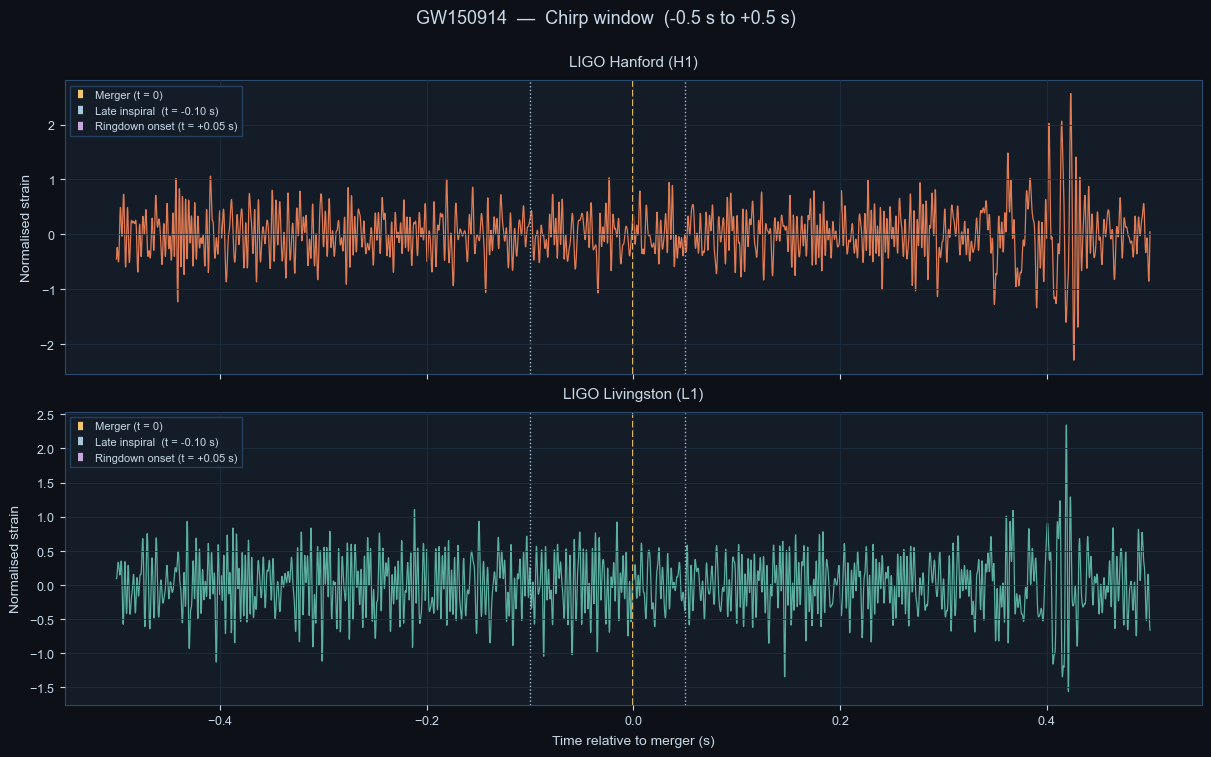

Figure saved → data\visualisations\GW150914_chirp_zoom.png


In [15]:
# Phase marker times are read from PHASE_MARKERS[EVENT.NAME] in config.py.
# Edit config.py to adapt to a different event — do not change values here.
inspiral_end    = phases.get("inspiral_end",   -0.1)
merger_t        = phases.get("merger",          0.0)
ringdown_start  = phases.get("ringdown_start",  0.05)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, det in zip(axes, EVENT.DETECTORS):
    colour = WA_COLOURS.get(det, "#7eb8e0")
    label  = EVENT.DETECTOR_LABELS.get(det, det)

    ts_crop = crop_to_window(processed[det], VIZ.TIMESERIES_WINDOW)
    t       = time_relative_to_merger(ts_crop)

    ax.plot(t, ts_crop.value, color=colour, lw=0.9)
    ax.set_title(label, fontsize=11, pad=10)
    ax.set_ylabel(VIZ.YLABEL_NORM_STRAIN)

    # Phase markers
    ax.axvline(merger_t,       color=WA_COLOURS["merger"],   lw=1.3, ls="--",
               label="Merger (t = 0)")
    ax.axvline(inspiral_end,   color=WA_COLOURS["inspiral"], lw=1.0, ls=":",
               label=f"Late inspiral  (t = {inspiral_end:+.2f} s)")
    ax.axvline(ringdown_start, color=WA_COLOURS["ringdown"], lw=1.0, ls=":",
               label=f"Ringdown onset (t = {ringdown_start:+.2f} s)")

    ax.legend(fontsize=8, loc="upper left")

axes[-1].set_xlabel(VIZ.XLABEL_TIME)
fig.suptitle(
    f"{EVENT.NAME}  —  Chirp window  "
    f"({VIZ.TIMESERIES_WINDOW[0]:+.1f} s to {VIZ.TIMESERIES_WINDOW[1]:+.1f} s)",
    fontsize=13, y=1.06
)
fig.savefig(PATHS.viz_output(EVENT.NAME, "chirp_zoom"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'chirp_zoom')}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 4 — Amplitude Spectral Density Comparison</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Side-by-side ASD of raw and processed data. The left panel shows the noise landscape that whitening must overcome; the right shows the result — a flattened spectrum where the signal band is accessible.</p>
</div>

### What the ASD comparison reveals

The ASD (√PSD) describes how noise *amplitude* varies with frequency. The key features in the raw ASD and what conditioning does to each:

| Feature | Raw ASD | After conditioning |
|---------|---------|-------------------|
| Seismic wall below 20 Hz | ASD rises steeply — 2–3 orders of magnitude above shot noise | Removed by bandpass |
| Mains lines at 60/120/180 Hz | Sharp spikes visibly above the continuum | Removed by notch filters |
| Shot noise floor above 200 Hz | Broad continuum, roughly flat | Whitening normalises this to ≈ 1 |
| Thermal noise 50–200 Hz | Moderate bump — the signal band | Whitening normalises; signal now detectable |

After whitening and filtering, the processed ASD is much flatter — all frequency bins contribute roughly equally to any downstream analysis.

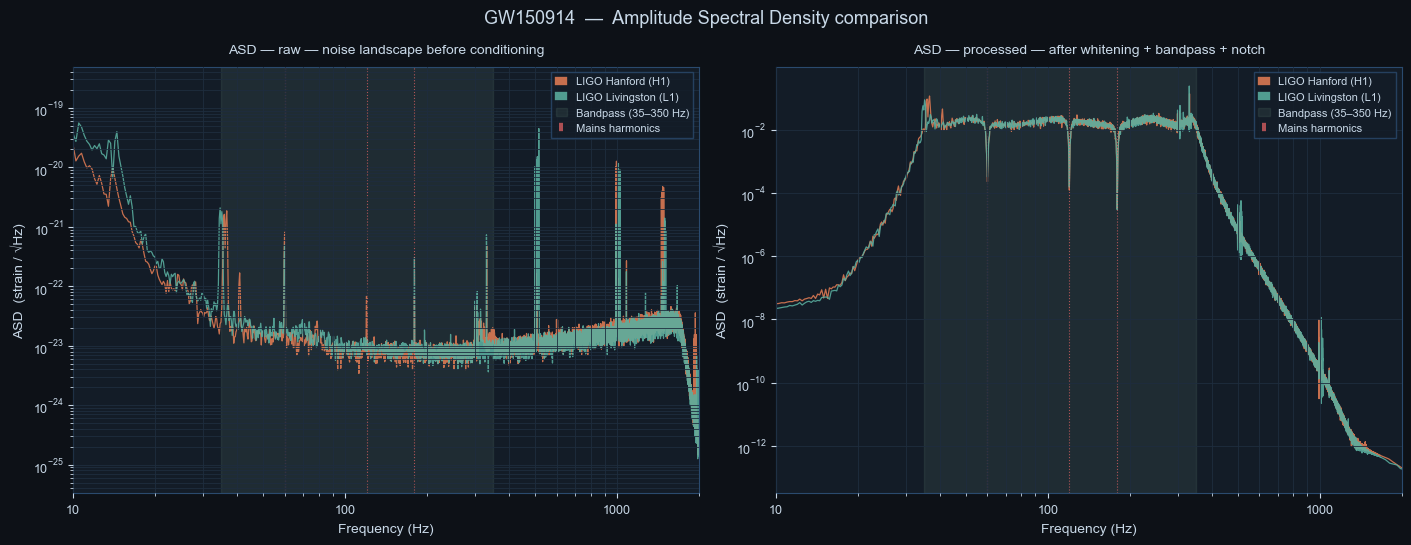

Figure saved → data\visualisations\GW150914_asd_comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data_dict, title_suffix in zip(
    axes,
    [raw, processed],
    ["raw — noise landscape before conditioning",
     "processed — after whitening + bandpass + notch"]
):
    for det, ts in data_dict.items():
        colour = WA_COLOURS.get(det, "#7eb8e0")
        asd = ts.asd(fftlength=SIGNAL.WHITEN_FFTLENGTH, method="median")
        ax.plot(asd.frequencies.value, asd.value,
                color=colour, lw=0.9, alpha=0.88,
                label=EVENT.DETECTOR_LABELS.get(det, det))

    ax.axvspan(SIGNAL.BANDPASS_LOW_HZ, SIGNAL.BANDPASS_HIGH_HZ,
               alpha=0.10, color=WA_COLOURS["bandpass"],
               label=f"Bandpass ({SIGNAL.BANDPASS_LOW_HZ:.0f}–{SIGNAL.BANDPASS_HIGH_HZ:.0f} Hz)")

    for i, freq in enumerate(SIGNAL.NOTCH_FREQS_HZ):
        ax.axvline(freq, color="#ff6b6b", lw=0.8, ls=":", alpha=0.65,
                   label="Mains harmonics" if i == 0 else "_nolegend_")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(10, 2000)
    ax.set_xlabel(VIZ.XLABEL_FREQ)
    ax.set_ylabel("ASD  (strain / √Hz)")
    ax.set_title(f"ASD — {title_suffix}", fontsize=10, pad=10)
    ax.legend(fontsize=8)

fig.suptitle(
    f"{EVENT.NAME}  —  Amplitude Spectral Density comparison",
    fontsize=13, y=1.06
)
fig.savefig(PATHS.viz_output(EVENT.NAME, "asd_comparison"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'asd_comparison')}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 5 — STFT Spectrogram</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">A time-frequency view using a fixed-window Short-Time Fourier Transform. Reveals how signal energy is distributed across frequency over time — and illustrates why the fixed-window limitation motivates the Q-transform in section 6.</p>
</div>

### Why use a spectrogram — and what are its limits?

A time-series plot shows amplitude vs time. An ASD shows power vs frequency (averaged). Neither shows both simultaneously — you cannot see a frequency sweep in either.

A **spectrogram** solves this by dividing the signal into short overlapping windows, computing the Fourier transform of each, and stacking the results as a 2D image: time on the x-axis, frequency on the y-axis, power as colour.

**The fixed-window limitation.** The STFT uses the same window length at all frequencies, forcing a trade-off:
- A short window gives good *time* resolution but poor *frequency* resolution
- A long window gives good *frequency* resolution but poor *time* resolution

For a chirp signal that sweeps from 35 Hz to 150 Hz in about 0.2 seconds, neither extreme is ideal. The Q-transform (section 6) resolves this by using frequency-dependent window lengths.

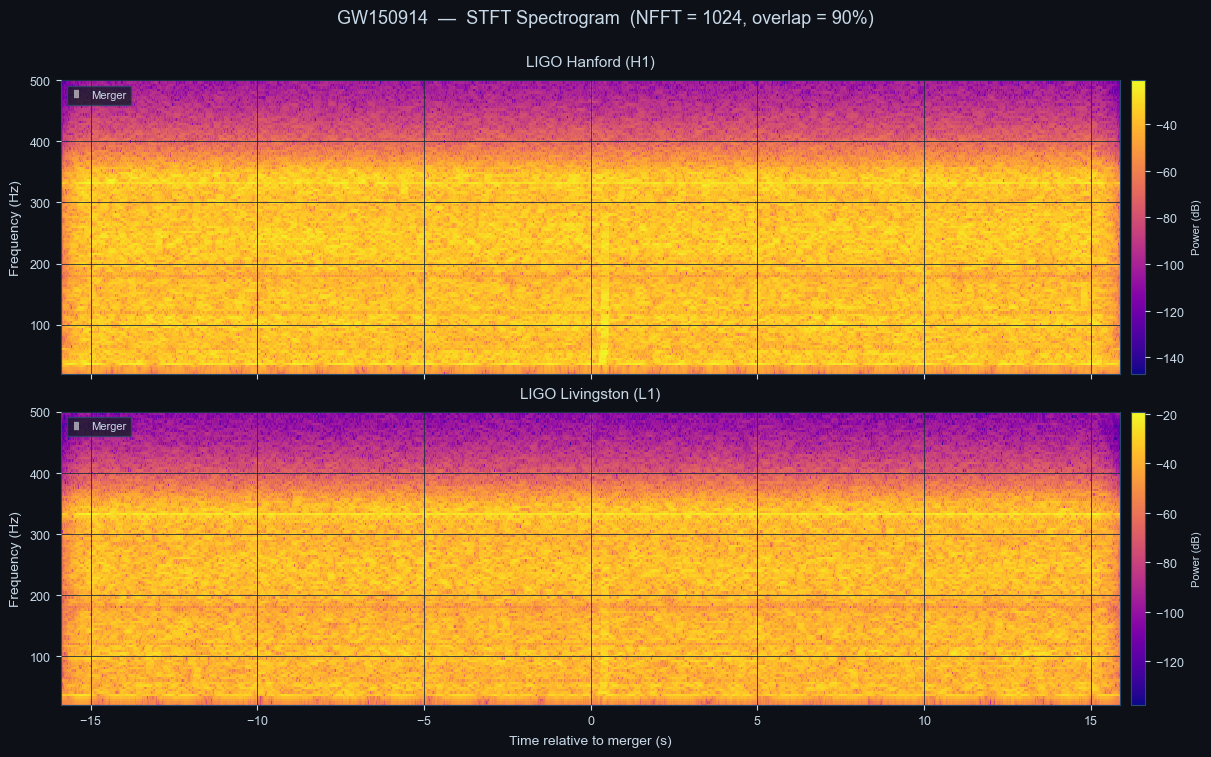

Figure saved → data\visualisations\GW150914_spectrogram_stft.png


In [13]:
NFFT     = VIZ.SPECGRAM_NFFT
NOVERLAP = int(NFFT * VIZ.SPECGRAM_OVERLAP)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, det in zip(axes, EVENT.DETECTORS):
    ts  = processed[det]
    sr  = float(ts.sample_rate.value)
    t_0 = ts.times.value[0] - EVENT.GPS_MERGE_TIME

    f, t_seg, Sxx = scipy_spectrogram(
        ts.value, fs=sr,
        nperseg=NFFT, noverlap=NOVERLAP,
        scaling="density",
    )
    t_rel  = t_seg + t_0
    f_mask = (f >= VIZ.SPECGRAM_FRANGE[0]) & (f <= VIZ.SPECGRAM_FRANGE[1])
    pwr_db = 10 * np.log10(Sxx[f_mask, :] + 1e-30)

    im = ax.pcolormesh(
        t_rel, f[f_mask], pwr_db,
        cmap=VIZ.COLOURMAP_SPECGRAM, shading="auto"
    )
    ax.set_ylabel(VIZ.XLABEL_FREQ)
    ax.set_ylim(VIZ.SPECGRAM_FRANGE)
    ax.set_title(
        EVENT.DETECTOR_LABELS.get(det, det),
        fontsize=11, pad=10
    )
    ax.axvline(0, color="white", lw=1.0, ls="--", alpha=0.55, label="Merger")
    ax.legend(fontsize=8, loc="upper left")

    cbar = fig.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label("Power (dB)", fontsize=8)

axes[-1].set_xlabel(VIZ.XLABEL_TIME)
fig.suptitle(
    f"{EVENT.NAME}  —  STFT Spectrogram  "
    f"(NFFT = {NFFT}, overlap = {int(VIZ.SPECGRAM_OVERLAP*100)}%)",
    fontsize=13, y=1.06
)
fig.savefig(PATHS.viz_output(EVENT.NAME, "spectrogram_stft"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'spectrogram_stft')}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 6 — Q-Transform: Individual Detectors</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">The gold standard for GW visualisation. Uses a frequency-dependent window width to achieve simultaneously good time <em>and</em> frequency resolution across the chirp band. Computed via <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">plot_qtransform()</code> from utils.py.</p>
</div>

### The Q-transform: variable-window time-frequency analysis

The Q-transform overcomes the fixed-window STFT limitation by using a **frequency-dependent Gaussian window** whose width scales inversely with frequency:

$$\Delta t(f) \propto \frac{Q}{f}$$

At **low frequencies** (e.g. 35 Hz) the window is wide — providing good frequency resolution where the chirp evolves slowly. At **high frequencies** (e.g. 150 Hz near merger) the window is narrow — providing good time resolution where the chirp sweeps rapidly. This is exactly matched to the physics of compact-binary inspirals.

The parameter **Q** controls the overall time-frequency trade-off. The algorithm searches over `VIZ.QTRANSFORM_QRANGE` = (7, 110) and returns the Q that best represents the signal at each frequency.

**What to look for in the plot:** A bright arc starting around 35–50 Hz at t ≈ −0.4 s, sweeping upward to ~150 Hz at the merger (t = 0), then abruptly fading as the black hole rings down. This is the direct observational signature of the inspiral — you are seeing the last 0.4 seconds of a 1.3-billion-year journey.

**Note on `plot_qtransform()`:** This function is defined in `utils.py`. It wraps gwpy's `TimeSeries.q_transform()` method, which handles the variable-window calculation internally. The function applies the theme colours, saves the figure, and returns the matplotlib figure object.

Computing Q-transform for H1 … (may take ~20 s)
Saved: data\visualisations\GW150914_qtransform_H1.png


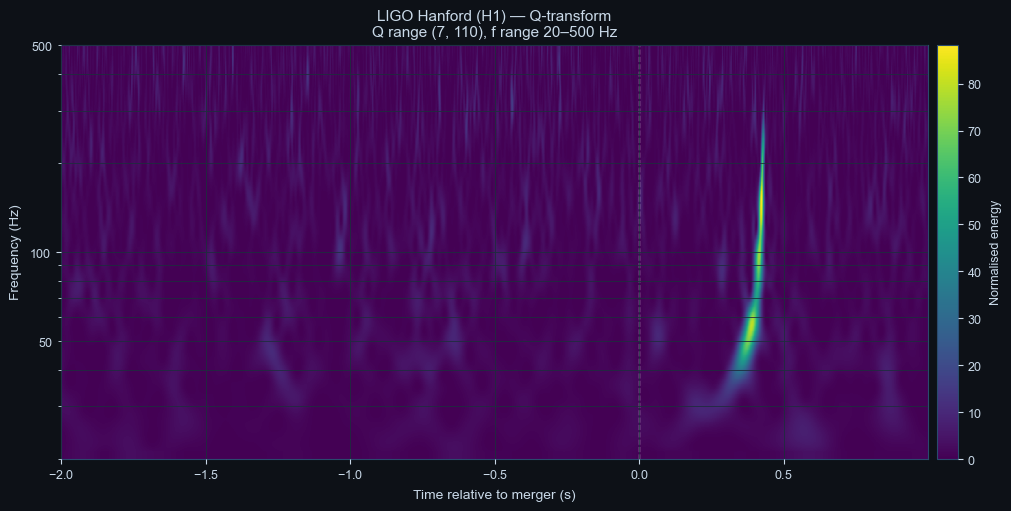

  ✓ H1 done.

Computing Q-transform for L1 … (may take ~20 s)
Saved: data\visualisations\GW150914_qtransform_L1.png


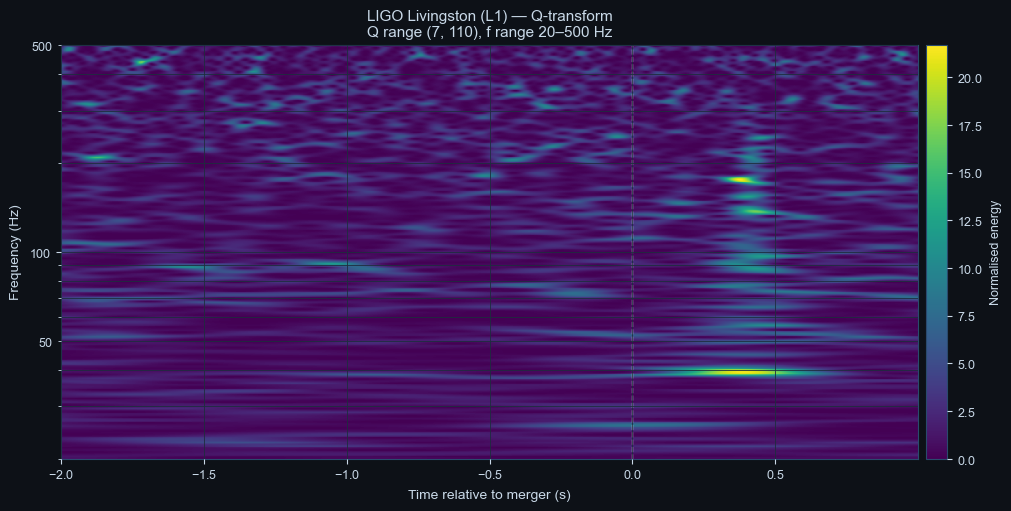

  ✓ L1 done.



In [8]:
# plot_qtransform() is defined in utils.py.
# Parameters are sourced from VIZ in config.py:
#   VIZ.QTRANSFORM_OUTSEG  — time window around merger (-2.0, 1.0) s
#   VIZ.QTRANSFORM_FRANGE  — frequency axis (20, 500) Hz
#   VIZ.QTRANSFORM_QRANGE  — Q search range (7, 110)
#   VIZ.QTRANSFORM_TRES    — time resolution 0.001 s
#
# The Q-transform is computationally heavier than the STFT spectrogram —
# expect ~20 s per detector. This is expected.

for det in EVENT.DETECTORS:
    print(f"Computing Q-transform for {det} … (may take ~20 s)")
    fig = plot_qtransform(
        ts        = processed[det],
        detector  = det,
        outseg    = VIZ.QTRANSFORM_OUTSEG,
        frange    = VIZ.QTRANSFORM_FRANGE,
        qrange    = VIZ.QTRANSFORM_QRANGE,
        save_path = PATHS.viz_output(EVENT.NAME, f"qtransform_{det}"),
    )
    plt.show()
    print(f"  ✓ {det} done.\n")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 7 — Q-Transform: H1 vs L1 Side-by-Side</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">The same chirp arc should appear in both independent detectors. A real gravitational wave passes through both; an instrumental glitch would not. The slight time offset (~7 ms for GW150914) encodes the sky position of the source.</p>
</div>

### Why the two-detector comparison matters

GW150914 was detected at both LIGO observatories, separated by ~3,000 km. The maximum light-travel time between them is ~10 ms. Any real astrophysical signal travelling at the speed of light must arrive with a delay consistent with this geometry.

GW150914 arrived at H1 (Hanford) **~7 ms before** L1 (Livingston). This 7 ms delay is consistent with a source located in the Southern sky, and combined with the antenna patterns of both detectors, it contributed to the sky localisation reported in the discovery paper.

If the chirp arc appears in both detectors at the same frequency and at the right time offset, it is extremely unlikely to be instrumental noise — glitches are local, not correlated across a continent.

Computing Q-transform for H1 …
Computing Q-transform for L1 …


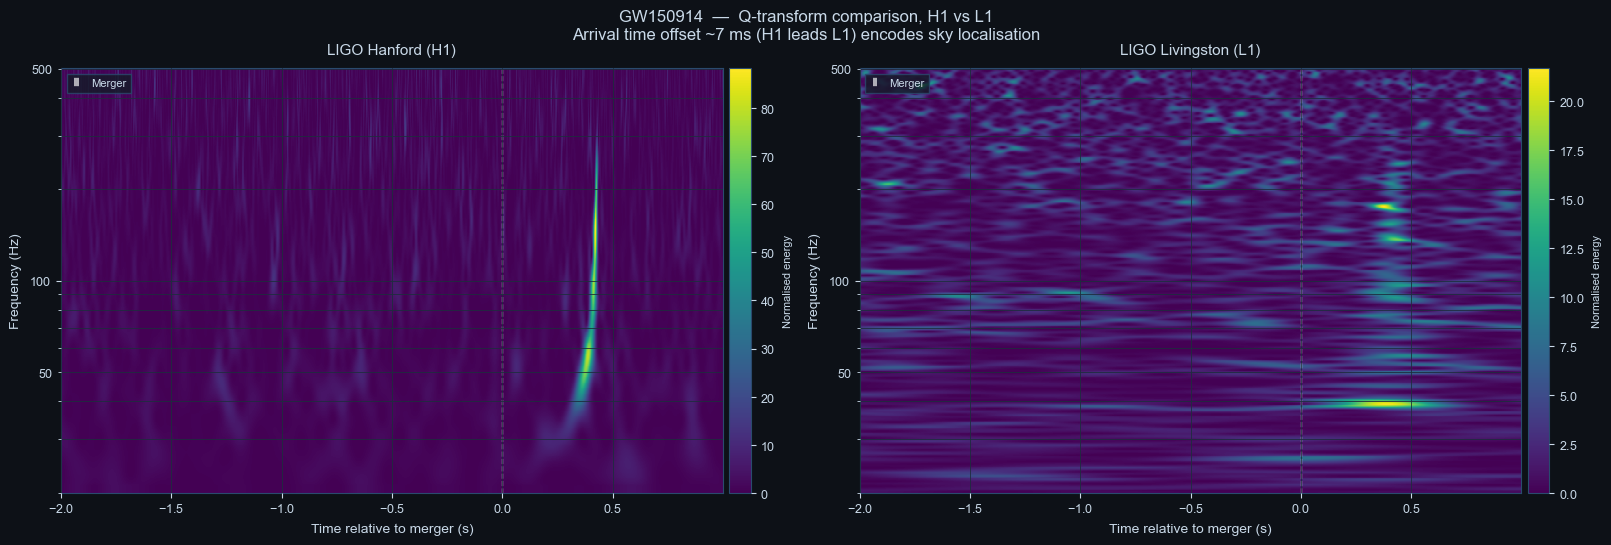

Figure saved → data\visualisations\GW150914_qtransform_comparison.png


In [17]:
abs_outseg = (
    EVENT.GPS_MERGE_TIME + VIZ.QTRANSFORM_OUTSEG[0],
    EVENT.GPS_MERGE_TIME + VIZ.QTRANSFORM_OUTSEG[1],
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, det in zip(axes, EVENT.DETECTORS):
    print(f"Computing Q-transform for {det} …")
    qt = processed[det].q_transform(
        qrange=VIZ.QTRANSFORM_QRANGE,
        frange=VIZ.QTRANSFORM_FRANGE,
        outseg=abs_outseg,
        tres=VIZ.QTRANSFORM_TRES,
        logf=True,
    )
    t_axis = qt.times.value - EVENT.GPS_MERGE_TIME
    f_axis = qt.frequencies.value

    im = ax.pcolormesh(
        t_axis, f_axis, qt.value.T,
        cmap=VIZ.COLOURMAP_QTRANS, shading="auto", vmin=0
    )
    ax.set_yscale("log")
    ax.set_xlabel(VIZ.XLABEL_TIME)
    ax.set_ylabel(VIZ.XLABEL_FREQ)
    ax.set_title(
        EVENT.DETECTOR_LABELS.get(det, det),
        fontsize=11, pad=10
    )
    ax.axvline(0, color="white", lw=1.0, ls="--", alpha=0.65, label="Merger")
    ax.legend(fontsize=8, loc="upper left")
    cbar = fig.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label("Normalised energy", fontsize=8)

fig.suptitle(
    f"{EVENT.NAME}  —  Q-transform comparison, H1 vs L1\n"
    "Arrival time offset ~7 ms (H1 leads L1) encodes sky localisation",
    fontsize=12, y=1.06
)
fig.savefig(PATHS.viz_output(EVENT.NAME, "qtransform_comparison"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'qtransform_comparison')}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 8 — Signal-to-Noise Estimate &amp; Window Visualisation</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Quantitative comparison of RMS amplitude in a quiet pre-merger window vs the signal window. This simple ratio provides intuition; proper matched-filter SNR (~24 for GW150914) is deferred to notebook 05.</p>
</div>

### Why the simple SNR is conservative

The RMS ratio $\text{SNR} = \sigma_{\text{signal}} / \sigma_{\text{noise}}$ treats the signal window as if it contained *only* signal. In reality, that 1-second window still contains residual noise as well as the actual chirp. This makes the estimate conservative — it systematically underestimates the true SNR.

The **matched-filter SNR** computed in notebook 05 will be much larger (~24 for GW150914) because it:
1. Correlates the data against a theoretical waveform template
2. Concentrates all signal power into a single peak rather than averaging over a window
3. Accounts for the full frequency-dependent noise power spectrum

In [10]:
# Compute SNR estimates using utils.estimate_snr()
print(f"{'Detector':<12} {'Noise RMS':<16} {'Signal RMS':<16} {'Simple SNR':<12}")
print("-" * 58)

snr_results = {}
for det, ts in processed.items():
    result = estimate_snr(
        ts,
        gps_merge_time = EVENT.GPS_MERGE_TIME,
        noise_window   = SIGNAL.NOISE_WINDOW,
        signal_window  = SIGNAL.SIGNAL_WINDOW,
    )
    snr_results[det] = result
    print(f"{det:<12} {result['noise_rms']:<16.4f} "
          f"{result['signal_rms']:<16.4f} {result['snr']:<12.2f}")

print()
print(f"  Noise window  : {SIGNAL.NOISE_WINDOW[0]:+.1f} to {SIGNAL.NOISE_WINDOW[1]:+.1f} s  (quiet region before merger)")
print(f"  Signal window : {SIGNAL.SIGNAL_WINDOW[0]:+.1f} to {SIGNAL.SIGNAL_WINDOW[1]:+.1f} s  (expected chirp region)")
print()
print("  Note: matched-filter SNR (~24) is computed in notebook 05.")

Detector     Noise RMS        Signal RMS       Simple SNR  
----------------------------------------------------------
H1           0.3389           0.4239           1.25        
L1           0.3447           0.3840           1.11        

  Noise window  : -15.0 to -5.0 s  (quiet region before merger)
  Signal window : -0.5 to +0.5 s  (expected chirp region)

  Note: matched-filter SNR (~24) is computed in notebook 05.


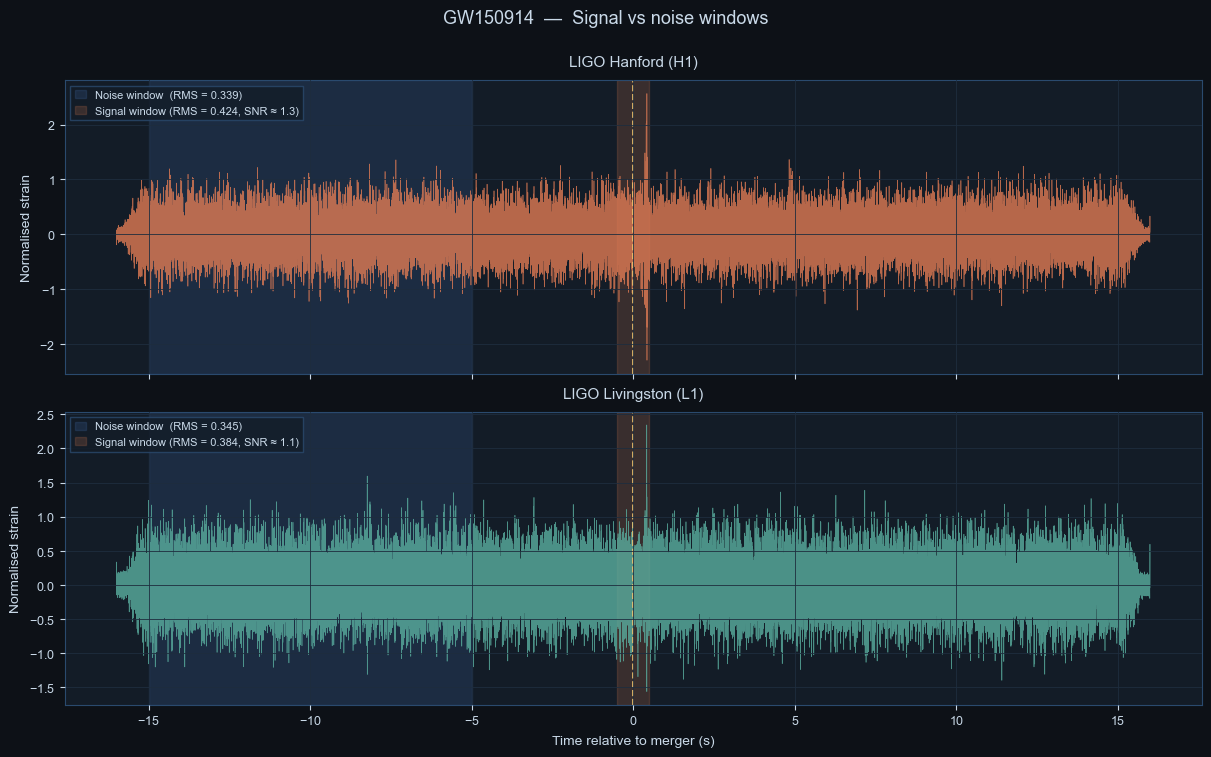

Figure saved → data\visualisations\GW150914_snr_windows.png


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, det in zip(axes, EVENT.DETECTORS):
    colour = WA_COLOURS.get(det, "#7eb8e0")
    ts     = processed[det]
    t      = time_relative_to_merger(ts)

    ax.plot(t, ts.value, color=colour, lw=0.45, alpha=0.8)

    ax.axvspan(*SIGNAL.NOISE_WINDOW,
               alpha=0.18, color=WA_COLOURS["noise_win"],
               label=f"Noise window  (RMS = {snr_results[det]['noise_rms']:.3f})")
    ax.axvspan(*SIGNAL.SIGNAL_WINDOW,
               alpha=0.22, color=WA_COLOURS["sig_win"],
               label=f"Signal window (RMS = {snr_results[det]['signal_rms']:.3f}, "
                     f"SNR ≈ {snr_results[det]['snr']:.1f})")
    ax.axvline(0, color=WA_COLOURS["merger"], lw=1.2, ls="--")
    ax.set_title(
        EVENT.DETECTOR_LABELS.get(det, det),
        fontsize=11, pad=10
    )
    ax.set_ylabel(VIZ.YLABEL_NORM_STRAIN)
    ax.legend(fontsize=8, loc="upper left")

axes[-1].set_xlabel(VIZ.XLABEL_TIME)
fig.suptitle(
    f"{EVENT.NAME}  —  Signal vs noise windows",
    fontsize=13, y=1.06
)
fig.savefig(PATHS.viz_output(EVENT.NAME, "snr_windows"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'snr_windows')}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 9 — Detector Correlation: Confirming the Signal Is Real</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Overlay H1 and L1 waveforms after applying the event-specific time shift and sign correction. If the signal is astrophysical, the chirps should align. Parameters are read from <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">DETECTOR_CORRELATION</code> in config.py.</p>
</div>

### The two-detector consistency check

One of the most important sanity checks for any gravitational wave detection is that the signal appears at **both detectors** with a physically consistent time delay and compatible amplitude.

A real gravitational wave is a distortion in spacetime — it travels at the speed of light and passes through both detectors. An instrumental glitch at one site would not, in general, appear at the other site at the correct time.

To visually confirm consistency, we overlay H1 and L1 waveforms after two corrections:
1. **Time shift** — L1 is shifted forward by the observed inter-site arrival delay (~7 ms for GW150914), so the chirps are aligned in time
2. **Sign flip** — the two detectors have different arm orientations, so the same wave produces strain with opposite polarity

After both corrections, the waveforms should overlap. The time shift and sign flip are defined per-event in `DETECTOR_CORRELATION` in `config.py` — the values here reflect the detailed analysis published with the GW150914 discovery paper. Both corrections vary by event, depending on sky position, wave polarisation, and source orientation relative to the detectors.

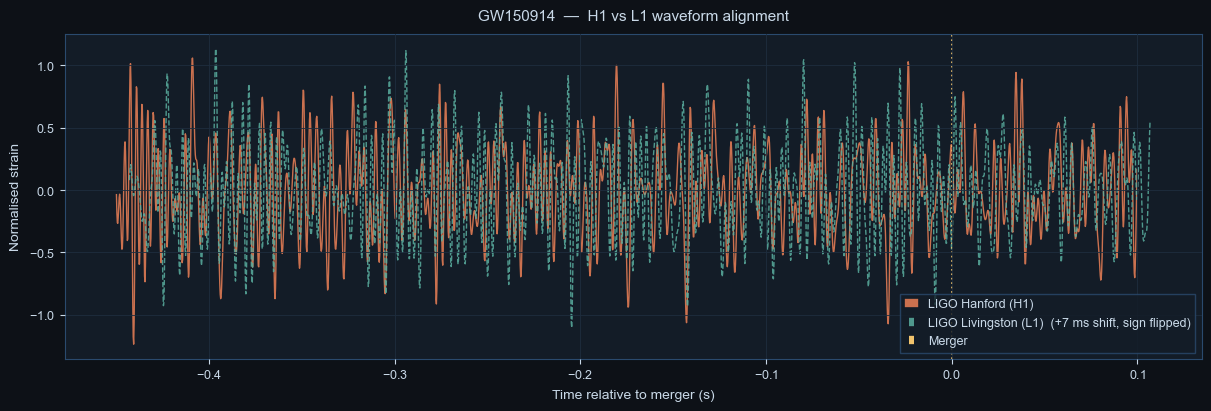

Figure saved → data\visualisations\GW150914_detector_correlation.png

If the waveforms align: the signal is coherent across both detectors.
Strong evidence of a real astrophysical event rather than an instrumental glitch.


In [12]:
# All event-specific parameters are read from DETECTOR_CORRELATION in config.py.
# Do not hard-code these values here — edit config.py to change them.
time_shift_s = corr.get("time_shift_s",  0.007)
sign_flip    = corr.get("sign_flip",    -1)
crop_win     = corr.get("crop_window",  (-0.45, 0.10))

h1_crop = crop_to_window(processed["H1"], crop_win)
l1_crop = crop_to_window(processed["L1"], crop_win)

t_h1 = time_relative_to_merger(h1_crop)
t_l1 = time_relative_to_merger(l1_crop) + time_shift_s

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(t_h1, h1_crop.value,
        color=WA_COLOURS["H1"], lw=1.0, alpha=0.9,
        label=EVENT.DETECTOR_LABELS.get("H1", "H1"))
ax.plot(t_l1, sign_flip * l1_crop.value,
        color=WA_COLOURS["L1"], lw=1.0, ls="--", alpha=0.85,
        label=f"{EVENT.DETECTOR_LABELS.get('L1','L1')}  "
              f"(+{int(time_shift_s*1000)} ms shift, "
              f"sign {'flipped' if sign_flip == -1 else 'unchanged'})")

ax.axvline(0, color=WA_COLOURS["merger"], lw=1.2, ls=":", label="Merger")
ax.set_xlabel(VIZ.XLABEL_TIME)
ax.set_ylabel(VIZ.YLABEL_NORM_STRAIN)
ax.set_title(
    f"{EVENT.NAME}  —  H1 vs L1 waveform alignment",
    fontsize=11, pad=10
)
ax.legend(fontsize=9)

fig.savefig(PATHS.viz_output(EVENT.NAME, "detector_correlation"),
            dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PATHS.viz_output(EVENT.NAME, 'detector_correlation')}")
print()
print("If the waveforms align: the signal is coherent across both detectors.")
print("Strong evidence of a real astrophysical event rather than an instrumental glitch.")

<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 100%); padding: 28px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-top: 16px;">

<h2 style="color: #e8f4fd; font-weight: 300; margin: 0 0 18px 0; font-size: 1.4em;">Summary &amp; Next Steps</h2>

<p style="color: #a0c4de; margin: 0 0 16px 0;"><strong style="color: #e8f4fd;">What this notebook covered:</strong></p>

<ul style="color: #c8dce8; margin: 0 0 20px 0; padding-left: 20px; line-height: 1.8;">
<li>Full-segment overview with merger-centred inset zoom (raw vs processed, both detectors)</li>
<li>Zoomed chirp window with event-specific <strong style="color: #e8f4fd;">phase markers</strong> from <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">PHASE_MARKERS</code> in config.py</li>
<li>Side-by-side ASD comparison showing the noise floor before and after conditioning</li>
<li>STFT spectrogram — illustrating fixed-window trade-offs</li>
<li>Q-transform (per-detector and side-by-side) — the chirp arc as a time-frequency sweep</li>
<li>Quantitative SNR estimation using <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">estimate_snr()</code> from utils.py</li>
<li>Detector correlation check with event-specific <strong style="color: #e8f4fd;">time shift and sign flip</strong> from <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">DETECTOR_CORRELATION</code> in config.py</li>
</ul>

<p style="color: #a0c4de; margin: 0 0 10px 0;"><strong style="color: #e8f4fd;">Outputs written:</strong></p>
<pre style="background: rgba(78,158,202,0.08); border: 1px solid rgba(78,158,202,0.2); border-radius: 6px; padding: 12px 16px; color: #7eb8e0; font-size: 0.9em; margin: 0 0 20px 0;">
data/visualisations/
├── GW150914_overview_raw_vs_processed.png
├── GW150914_chirp_zoom.png
├── GW150914_asd_comparison.png
├── GW150914_spectrogram_stft.png
├── GW150914_qtransform_H1.png
├── GW150914_qtransform_L1.png
├── GW150914_qtransform_comparison.png
├── GW150914_snr_windows.png
└── GW150914_detector_correlation.png
</pre>

<p style="color: #a0c4de; margin: 0 0 6px 0;"><strong style="color: #e8f4fd;">Next — <code style="background: rgba(78,158,202,0.15); padding: 2px 6px; border-radius: 3px; color: #7eb8e0;">04_feature_extraction.ipynb</code>:</strong></p>
<p style="color: #c8dce8; margin: 0;">Extract quantitative features from the processed strain and Q-transform — peak frequency, chirp mass estimate, SNR time series, spectral centroid — to build a feature matrix for classification and modelling in notebooks 05 and 06.</p>

</div>